# Classifying Alzheimer's Disease Using Deep Learning on fMRI
## Dual-Stream Fusion Model (GCN + BiLSTM) - Novel Contribution

**Student:** Kirankumar Chikkamankanala Somashekar
**Date:** August 26, 2026 | **Version:** v1
**Dataset:** 218 subjects (109 AD, 109 CN) for BOTH streams (per Keith's guidance)

**Current standings:**
- SVM Linear [262 subj]: 71.3% / 0.777 AUC
- BiLSTM h128 L1 mean [218 subj]: 69.3% / 0.742 AUC
- GCN+Skip Thresh-0.2 [262 subj]: 66.4% / 0.740 AUC

**Novel contribution:** Combine spatial (GCN on FC) and temporal (BiLSTM on BOLD) streams.
The question: does combining two complementary views of the brain improve classification
beyond what either view achieves alone?

---
**Contents:**
1. Setup
2. Data Loading
3. Fusion Model Architecture
4. Training Engine
5. Experiments
6. Results and Comparison
7. Save All Results

## 1. Setup

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch_geometric -q

import numpy as np
import pandas as pd
import pickle, os, copy, time, warnings
from datetime import datetime
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader as TorchDataLoader

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
from torch_geometric.utils import dense_to_sparse

from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix, roc_curve, auc)

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':300,'font.size':11,
                     'axes.titlesize':13,'axes.titleweight':'bold','savefig.bbox':'tight'})

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

Mounted at /content/drive
Device: cuda | PyTorch: 2.11.0+cu128


In [ ]:
BASE = '/content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/data'
RESULTS_BASE = '/content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results'
NB_RESULTS = os.path.join(RESULTS_BASE, 'nb04_fusion')
NB_FIGURES = os.path.join(NB_RESULTS, 'figures')
os.makedirs(NB_RESULTS, exist_ok=True)
os.makedirs(NB_FIGURES, exist_ok=True)
print(f'Data: {BASE}\nResults: {NB_RESULTS}')

Data: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/data
Results: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb04_fusion


## 2. Data Loading

In [ ]:
# Both streams use the SAME 218 TR=3.0s subjects (Keith's guidance)

# GCN stream: FC matrices for spatial connectivity
fc_matrices_tr3 = np.load(f'{BASE}/fc_matrices_stacked_tr3.npy')  # (218, 132, 132)
node_features_tr3 = np.load(f'{BASE}/node_features_tr3.npy')      # (218, 132, 132)

# BiLSTM stream: raw BOLD for temporal dynamics
X_bold = np.load(f'{BASE}/X_bold_tr3.npy')     # (218, 191, 132)
y = np.load(f'{BASE}/y_labels_tr3.npy')         # (218,)
subject_ids = np.load(f'{BASE}/subject_ids_tr3.npy', allow_pickle=True)

with open(f'{BASE}/cv_folds_bilstm.pkl', 'rb') as f:
    cv_folds = pickle.load(f)

# Load all previous results
with open(os.path.join(RESULTS_BASE,'nb01_baseline','baseline_results.pkl'),'rb') as f:
    bl = pickle.load(f)
with open(os.path.join(RESULTS_BASE,'nb02_gcn','gcn_results.pkl'),'rb') as f:
    gcn_res = pickle.load(f)
with open(os.path.join(RESULTS_BASE,'nb03_bilstm','bilstm_results.pkl'),'rb') as f:
    lstm_res = pickle.load(f)

N_SUBJECTS, T, N_ROIS = X_bold.shape
M = fc_matrices_tr3.shape[1]

print(f'GCN stream:    {fc_matrices_tr3.shape} FC matrices')
print(f'BiLSTM stream: {X_bold.shape} BOLD time series')
print(f'Labels: CN={int((y==0).sum())}, AD={int((y==1).sum())}')
print(f'Subjects match: {len(fc_matrices_tr3)==len(X_bold)==len(y)}')

GCN stream:    (218, 132, 132) FC matrices
BiLSTM stream: (218, 191, 132) BOLD time series
Labels: CN=109, AD=109
Subjects match: True


## 3. Fusion Model Architecture

### 3.1 Build Graphs for GCN Stream

In [ ]:
def build_graphs_knn(fc_mats, labels, k=10):
    """Build KNN graphs from FC matrices."""
    graphs = []
    for i in range(len(fc_mats)):
        fc = np.abs(fc_mats[i].copy())
        np.fill_diagonal(fc, 0)
        fc = np.clip(fc, 0, 3.0)
        x = fc / (fc.max() + 1e-8)
        x = torch.tensor(x, dtype=torch.float32)
        adj = np.zeros_like(fc)
        for row in range(fc.shape[0]):
            top_k = np.argsort(fc[row])[-k:]
            adj[row, top_k] = fc[row, top_k]
        adj = np.maximum(adj, adj.T)
        if adj.max() > 0: adj = adj / adj.max()
        adj_t = torch.tensor(adj, dtype=torch.float32)
        edge_index, edge_attr = dense_to_sparse(adj_t)
        y_t = torch.tensor([int(labels[i])], dtype=torch.long)
        graphs.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y_t))
    return graphs

def build_graphs_thresh(fc_mats, labels, threshold=0.2):
    """Build threshold graphs from FC matrices."""
    graphs = []
    for i in range(len(fc_mats)):
        fc = np.abs(fc_mats[i].copy())
        np.fill_diagonal(fc, 0)
        fc = np.clip(fc, 0, 3.0)
        x = fc / (fc.max() + 1e-8)
        x = torch.tensor(x, dtype=torch.float32)
        adj = fc.copy()
        adj[adj < threshold] = 0
        if adj.max() > 0: adj = adj / adj.max()
        adj_t = torch.tensor(adj, dtype=torch.float32)
        edge_index, edge_attr = dense_to_sparse(adj_t)
        y_t = torch.tensor([int(labels[i])], dtype=torch.long)
        graphs.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y_t))
    return graphs

print('Building graphs...')
graphs_thresh = build_graphs_thresh(fc_matrices_tr3, y, threshold=0.2)
graphs_knn = build_graphs_knn(fc_matrices_tr3, y, k=10)
print(f'Threshold 0.2: {len(graphs_thresh)} graphs, edges={graphs_thresh[0].edge_index.shape[1]}')
print(f'KNN-10: {len(graphs_knn)} graphs, edges={graphs_knn[0].edge_index.shape[1]}')

Building graphs...
Threshold 0.2: 218 graphs, edges=8980
KNN-10: 218 graphs, edges=1754


### 3.2 Dual-Stream Fusion Model

**Architecture:**
```
Stream 1 (Spatial - GCN):
  FC matrix -> GCN+Skip -> global pooling -> spatial_embed (d-dim)

Stream 2 (Temporal - BiLSTM):
  Raw BOLD -> input_proj -> BiLSTM -> mean pooling -> temporal_embed (d-dim)

Fusion:
  Option A: concat(spatial, temporal) -> classifier
  Option B: attention-weighted combination
```

In [ ]:
class SpatialStream(nn.Module):
    """GCN+Skip stream for spatial connectivity features."""
    def __init__(self, in_ch, hidden, n_layers=2, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.convs.append(GCNConv(in_ch, hidden))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(n_layers-1):
            self.convs.append(GCNConv(hidden, hidden))
            self.bns.append(nn.BatchNorm1d(hidden))
        self.skip_proj = nn.Linear(in_ch, hidden)
        self.skip_bn = nn.BatchNorm1d(hidden)

    def forward(self, x, edge_index, edge_attr, batch):
        # Skip path
        x_skip = F.relu(self.skip_bn(self.skip_proj(x)))
        x_skip = torch.cat([global_mean_pool(x_skip, batch),
                            global_max_pool(x_skip, batch)], dim=1)
        # GCN path
        x_conv = x
        for conv, bn in zip(self.convs, self.bns):
            x_new = F.relu(bn(conv(x_conv, edge_index, edge_weight=edge_attr)))
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)
            if x_conv.shape == x_new.shape: x_conv = x_conv + x_new
            else: x_conv = x_new
        x_conv = torch.cat([global_mean_pool(x_conv, batch),
                            global_max_pool(x_conv, batch)], dim=1)
        return torch.cat([x_conv, x_skip], dim=1)  # (B, hidden*4)


class TemporalStream(nn.Module):
    """BiLSTM stream for temporal dynamics."""
    def __init__(self, input_size, hidden, num_layers=1, dropout=0.5):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, hidden), nn.LayerNorm(hidden),
            nn.ReLU(), nn.Dropout(dropout*0.5))
        self.lstm = nn.LSTM(hidden, hidden, num_layers, batch_first=True,
                           bidirectional=True, dropout=dropout if num_layers>1 else 0)
        self.ln = nn.LayerNorm(hidden*2)

    def forward(self, x):
        x = self.input_proj(x)
        out, _ = self.lstm(x)
        out = self.ln(out)
        return out.mean(dim=1)  # mean pooling -> (B, hidden*2)


class DualStreamFusion(nn.Module):
    """
    Dual-stream fusion: spatial (GCN) + temporal (BiLSTM).
    Novel contribution: combines FC connectivity patterns with BOLD temporal dynamics.
    """
    def __init__(self, n_rois=132, hidden=64, gcn_layers=2, lstm_layers=1,
                 dropout=0.5, fusion='concat', n_classes=2):
        super().__init__()
        self.fusion_type = fusion

        # Stream 1: Spatial (GCN with skip connection)
        self.spatial = SpatialStream(n_rois, hidden, gcn_layers, dropout)
        spatial_dim = hidden * 4  # conv(mean+max) + skip(mean+max)

        # Stream 2: Temporal (BiLSTM with mean pooling)
        self.temporal = TemporalStream(n_rois, hidden, lstm_layers, dropout)
        temporal_dim = hidden * 2  # bidirectional

        # Fusion
        if fusion == 'concat':
            fused_dim = spatial_dim + temporal_dim
        elif fusion == 'attention':
            # Project both to same dim, then learn attention
            self.spatial_proj = nn.Linear(spatial_dim, hidden)
            self.temporal_proj = nn.Linear(temporal_dim, hidden)
            self.attn_gate = nn.Sequential(
                nn.Linear(hidden * 2, hidden),
                nn.ReLU(),
                nn.Linear(hidden, 2),
                nn.Softmax(dim=1)
            )
            fused_dim = hidden

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes)
        )
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, graph_data, bold_data):
        # Spatial stream
        s = self.spatial(graph_data.x, graph_data.edge_index,
                         graph_data.edge_attr, graph_data.batch)

        # Temporal stream
        t = self.temporal(bold_data)

        # Fusion
        if self.fusion_type == 'concat':
            fused = torch.cat([s, t], dim=1)
        elif self.fusion_type == 'attention':
            s_proj = F.relu(self.spatial_proj(s))
            t_proj = F.relu(self.temporal_proj(t))
            attn = self.attn_gate(torch.cat([s_proj, t_proj], dim=1))
            self.stream_weights = attn  # save for analysis
            fused = attn[:,0:1] * s_proj + attn[:,1:2] * t_proj

        return self.classifier(fused)


# Test
for fusion in ['concat', 'attention']:
    m = DualStreamFusion(n_rois=132, hidden=64, fusion=fusion)
    print(f'Fusion ({fusion}): {sum(p.numel() for p in m.parameters()):,} params')

Fusion (concat): 121,922 params
Fusion (attention): 134,532 params


## 4. Training Engine

### 4.1 Fusion Dataset and Collation

In [ ]:
class FusionDataset:
    """Wraps paired graph + BOLD data for the fusion model."""
    def __init__(self, graphs, bold_data, labels):
        self.graphs = graphs
        self.bold = torch.tensor(bold_data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return self.graphs[idx], self.bold[idx], self.labels[idx]


def fusion_collate(batch):
    """Custom collate: batch graphs via PyG, stack BOLD tensors."""
    from torch_geometric.data import Batch
    graphs = [item[0] for item in batch]
    bolds = torch.stack([item[1] for item in batch])
    labels = torch.stack([item[2] for item in batch])
    graph_batch = Batch.from_data_list(graphs)
    return graph_batch, bolds, labels

print('Fusion dataset and collation defined.')

Fusion dataset and collation defined.


### 4.2 Training and Evaluation Functions

In [ ]:
def train_epoch_fusion(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for graph_batch, bold_batch, labels in loader:
        graph_batch = graph_batch.to(device)
        bold_batch = bold_batch.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        out = model(graph_batch, bold_batch)
        if torch.isnan(out).any(): continue
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(labels)
        correct += (out.argmax(1)==labels).sum().item()
        total += len(labels)
    return total_loss/max(total,1), correct/max(total,1)


@torch.no_grad()
def eval_fusion(model, loader, device):
    model.eval()
    preds, probs, labels_all, total_loss = [], [], [], 0
    crit = nn.CrossEntropyLoss()
    for graph_batch, bold_batch, labels in loader:
        graph_batch = graph_batch.to(device)
        bold_batch = bold_batch.to(device)
        labels = labels.to(device)
        out = model(graph_batch, bold_batch)
        if torch.isnan(out).any(): out = torch.nan_to_num(out)
        total_loss += crit(out, labels).item() * len(labels)
        p = F.softmax(out, dim=1)
        preds.extend(out.argmax(1).cpu().numpy())
        probs.extend(p[:,1].cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    return np.array(preds), np.array(probs), np.array(labels_all), total_loss/len(loader.dataset)

print('Training functions defined.')

Training functions defined.


In [ ]:
def run_fusion_cv(graphs, X_bold, y, cv_folds, config, device):
    """Run fusion model with 5-fold CV."""
    t_start = time.time()
    metrics = {k:[] for k in ['accuracy','f1','precision','recall','auc_roc']}
    all_true, all_pred, all_prob = [], [], []
    histories = []
    stream_weights_all = []  # for attention fusion analysis

    print(f'\n{"="*60}')
    print(f'{config["name"]}')
    print(f'GCN: h{config["hidden"]} L{config["gcn_layers"]} | '
          f'LSTM: h{config["hidden"]} L{config["lstm_layers"]} | '
          f'Fusion: {config["fusion"]} | Drop: {config["dropout"]}')
    print(f'{"="*60}')

    for fi, (tr_idx, te_idx) in enumerate(cv_folds):
        tr_ds = FusionDataset([graphs[i] for i in tr_idx], X_bold[tr_idx], y[tr_idx])
        te_ds = FusionDataset([graphs[i] for i in te_idx], X_bold[te_idx], y[te_idx])
        tr_ld = TorchDataLoader(tr_ds, batch_size=config['bs'], shuffle=True, collate_fn=fusion_collate)
        te_ld = TorchDataLoader(te_ds, batch_size=config['bs'], shuffle=False, collate_fn=fusion_collate)

        model = DualStreamFusion(
            n_rois=M, hidden=config['hidden'],
            gcn_layers=config['gcn_layers'], lstm_layers=config['lstm_layers'],
            dropout=config['dropout'], fusion=config['fusion']
        ).to(device)

        opt = Adam(model.parameters(), lr=config['lr'], weight_decay=config['wd'])
        crit = nn.CrossEntropyLoss()
        sched = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=15)

        best_loss, best_state, wait = float('inf'), copy.deepcopy(model.state_dict()), 0
        hist = {'tl':[],'vl':[],'ta':[],'va':[]}

        for ep in range(config['epochs']):
            tl, ta = train_epoch_fusion(model, tr_ld, opt, crit, device)
            pr, pb, lb, vl = eval_fusion(model, te_ld, device)
            va = accuracy_score(lb, pr)
            hist['tl'].append(tl); hist['vl'].append(vl)
            hist['ta'].append(ta); hist['va'].append(va)
            sched.step(vl)
            if vl < best_loss:
                best_loss = vl; best_state = copy.deepcopy(model.state_dict()); wait = 0
            else: wait += 1
            if wait >= config['patience']: break

        model.load_state_dict(best_state)
        pr, pb, lb, _ = eval_fusion(model, te_ld, device)

        # Collect attention weights if applicable
        if config['fusion'] == 'attention' and hasattr(model, 'stream_weights'):
            stream_weights_all.append(model.stream_weights.cpu().numpy())

        acc = accuracy_score(lb,pr); f1 = f1_score(lb,pr,average='macro',zero_division=0)
        prec = precision_score(lb,pr,average='macro',zero_division=0)
        rec = recall_score(lb,pr,average='macro',zero_division=0)
        try: auc_v = roc_auc_score(lb,pb)
        except: auc_v = 0.5

        for k,v in zip(metrics.keys(),[acc,f1,prec,rec,auc_v]): metrics[k].append(v)
        all_true.extend(lb.tolist()); all_pred.extend(pr.tolist()); all_prob.extend(pb.tolist())
        histories.append(hist)
        print(f'  Fold {fi+1}: Acc={acc:.4f} F1={f1:.4f} AUC={auc_v:.4f} Ep={len(hist["tl"])}')

    elapsed = time.time() - t_start
    res = {'model_name':config['name'], 'model_type':'fusion', 'n_subjects':N_SUBJECTS,
           'n_features':'spatial+temporal', 'config':config,
           'training_time_seconds':elapsed, 'fold_histories':histories,
           'y_true_all':all_true, 'y_pred_all':all_pred, 'y_prob_all':all_prob,
           'stream_weights':stream_weights_all,
           'date':datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    for m in metrics:
        res[f'{m}_mean']=np.mean(metrics[m]); res[f'{m}_std']=np.std(metrics[m])
        res[f'{m}_per_fold']=metrics[m]

    print(f'  >> Acc={res["accuracy_mean"]:.4f}+/-{res["accuracy_std"]:.4f} '
          f'AUC={res["auc_roc_mean"]:.4f}+/-{res["auc_roc_std"]:.4f} ({elapsed:.0f}s)')
    return res

print('CV runner defined.')

CV runner defined.


## 5. Experiments

### 5.1 Concatenation Fusion (Default)

In [ ]:
tc = {'bs':32, 'epochs':300, 'patience':30, 'lr':1e-3, 'wd':5e-4}
all_results = []

# Concat fusion with threshold graph
cfg = {**tc, 'name':'Fusion Concat Thresh-0.2 h64',
       'hidden':64, 'gcn_layers':2, 'lstm_layers':1, 'dropout':0.5, 'fusion':'concat'}
r = run_fusion_cv(graphs_thresh, X_bold, y, cv_folds, cfg, DEVICE)
all_results.append(r)

# Concat fusion with KNN graph
cfg = {**tc, 'name':'Fusion Concat KNN-10 h64',
       'hidden':64, 'gcn_layers':2, 'lstm_layers':1, 'dropout':0.5, 'fusion':'concat'}
r = run_fusion_cv(graphs_knn, X_bold, y, cv_folds, cfg, DEVICE)
all_results.append(r)


Fusion Concat Thresh-0.2 h64
GCN: h64 L2 | LSTM: h64 L1 | Fusion: concat | Drop: 0.5
  Fold 1: Acc=0.7708 F1=0.7683 AUC=0.8783 Ep=65
  Fold 2: Acc=0.6047 F1=0.5820 AUC=0.6840 Ep=39
  Fold 3: Acc=0.6750 F1=0.6366 AUC=0.8095 Ep=39
  Fold 4: Acc=0.6818 F1=0.6709 AUC=0.7231 Ep=39
  Fold 5: Acc=0.5349 F1=0.5346 AUC=0.6450 Ep=37
  >> Acc=0.6534+/-0.0794 AUC=0.7480+/-0.0849 (31s)

Fusion Concat KNN-10 h64
GCN: h64 L2 | LSTM: h64 L1 | Fusion: concat | Drop: 0.5
  Fold 1: Acc=0.6250 F1=0.6190 AUC=0.6765 Ep=35
  Fold 2: Acc=0.6744 F1=0.6742 AUC=0.7208 Ep=39
  Fold 3: Acc=0.7250 F1=0.7206 AUC=0.7920 Ep=43
  Fold 4: Acc=0.5000 F1=0.3333 AUC=0.4773 Ep=31
  Fold 5: Acc=0.6047 F1=0.6047 AUC=0.6299 Ep=37
  >> Acc=0.6258+/-0.0755 AUC=0.6593+/-0.1055 (19s)


### 5.2 Attention Fusion

In [ ]:
# Attention fusion with threshold graph
cfg = {**tc, 'name':'Fusion Attention Thresh-0.2 h64',
       'hidden':64, 'gcn_layers':2, 'lstm_layers':1, 'dropout':0.5, 'fusion':'attention'}
r = run_fusion_cv(graphs_thresh, X_bold, y, cv_folds, cfg, DEVICE)
all_results.append(r)

# Attention fusion with KNN graph
cfg = {**tc, 'name':'Fusion Attention KNN-10 h64',
       'hidden':64, 'gcn_layers':2, 'lstm_layers':1, 'dropout':0.5, 'fusion':'attention'}
r = run_fusion_cv(graphs_knn, X_bold, y, cv_folds, cfg, DEVICE)
all_results.append(r)


Fusion Attention Thresh-0.2 h64
GCN: h64 L2 | LSTM: h64 L1 | Fusion: attention | Drop: 0.5
  Fold 1: Acc=0.7500 F1=0.7387 AUC=0.7896 Ep=38
  Fold 2: Acc=0.6047 F1=0.5905 AUC=0.6212 Ep=37
  Fold 3: Acc=0.5250 F1=0.4997 AUC=0.5940 Ep=32
  Fold 4: Acc=0.5000 F1=0.4958 AUC=0.6591 Ep=35
  Fold 5: Acc=0.6047 F1=0.5411 AUC=0.6558 Ep=33
  >> Acc=0.5969+/-0.0873 AUC=0.6639+/-0.0672 (25s)

Fusion Attention KNN-10 h64
GCN: h64 L2 | LSTM: h64 L1 | Fusion: attention | Drop: 0.5
  Fold 1: Acc=0.7292 F1=0.7281 AUC=0.7930 Ep=41
  Fold 2: Acc=0.6744 F1=0.6728 AUC=0.7706 Ep=40
  Fold 3: Acc=0.6500 F1=0.6354 AUC=0.7544 Ep=40
  Fold 4: Acc=0.5000 F1=0.3333 AUC=0.5186 Ep=31
  Fold 5: Acc=0.7674 F1=0.7643 AUC=0.8398 Ep=41
  >> Acc=0.6642+/-0.0918 AUC=0.7353+/-0.1121 (21s)


### 5.3 Larger Hidden Dimension

In [ ]:
# Best graph from 5.1/5.2 with h128
best_tmp = max(all_results, key=lambda r: r['accuracy_mean'])
best_fusion = best_tmp['config']['fusion']
best_graph_name = 'Thresh' if 'Thresh' in best_tmp['model_name'] else 'KNN'
best_graphs = graphs_thresh if 'Thresh' in best_tmp['model_name'] else graphs_knn
print(f'Best so far: {best_tmp["model_name"]} ({best_tmp["accuracy_mean"]:.4f})')

cfg = {**tc, 'name':f'Fusion {best_fusion.title()} {best_graph_name} h128',
       'hidden':128, 'gcn_layers':2, 'lstm_layers':1, 'dropout':0.5, 'fusion':best_fusion}
r = run_fusion_cv(best_graphs, X_bold, y, cv_folds, cfg, DEVICE)
all_results.append(r)

Best so far: Fusion Attention KNN-10 h64 (0.6642)

Fusion Attention KNN h128
GCN: h128 L2 | LSTM: h128 L1 | Fusion: attention | Drop: 0.5
  Fold 1: Acc=0.7292 F1=0.7290 AUC=0.8278 Ep=37
  Fold 2: Acc=0.5349 F1=0.5222 AUC=0.7186 Ep=36
  Fold 3: Acc=0.5750 F1=0.5402 AUC=0.7494 Ep=38
  Fold 4: Acc=0.6136 F1=0.6118 AUC=0.6116 Ep=38
  Fold 5: Acc=0.5116 F1=0.3385 AUC=0.6515 Ep=32
  >> Acc=0.5929+/-0.0765 AUC=0.7118+/-0.0756 (21s)


### 5.4 Fine-Tuning

In [ ]:
best_tmp = max(all_results, key=lambda r: r['accuracy_mean'])
best_h = best_tmp['config']['hidden']
best_f = best_tmp['config']['fusion']
print(f'Tuning from: {best_tmp["model_name"]} ({best_tmp["accuracy_mean"]:.4f})')

for ename, drop, lr, wd in [
    ('drop0.3', 0.3, 1e-3, 5e-4),
    ('lr5e-4', 0.5, 5e-4, 5e-4),
    ('drop0.3 lr5e-4', 0.3, 5e-4, 1e-4),
]:
    cfg = {**tc, 'name':f'Fusion Tuned h{best_h} {ename}',
           'hidden':best_h, 'gcn_layers':2, 'lstm_layers':1,
           'dropout':drop, 'fusion':best_f, 'lr':lr, 'wd':wd}
    r = run_fusion_cv(best_graphs, X_bold, y, cv_folds, cfg, DEVICE)
    all_results.append(r)

Tuning from: Fusion Attention KNN-10 h64 (0.6642)

Fusion Tuned h64 drop0.3
GCN: h64 L2 | LSTM: h64 L1 | Fusion: attention | Drop: 0.3
  Fold 1: Acc=0.7500 F1=0.7496 AUC=0.8487 Ep=64
  Fold 2: Acc=0.6279 F1=0.6261 AUC=0.7273 Ep=39
  Fold 3: Acc=0.6250 F1=0.6248 AUC=0.7243 Ep=39
  Fold 4: Acc=0.7955 F1=0.7953 AUC=0.7831 Ep=43
  Fold 5: Acc=0.5581 F1=0.5423 AUC=0.6061 Ep=33
  >> Acc=0.6713+/-0.0877 AUC=0.7379+/-0.0800 (25s)

Fusion Tuned h64 lr5e-4
GCN: h64 L2 | LSTM: h64 L1 | Fusion: attention | Drop: 0.5
  Fold 1: Acc=0.6875 F1=0.6874 AUC=0.7983 Ep=51
  Fold 2: Acc=0.5814 F1=0.5812 AUC=0.6797 Ep=42
  Fold 3: Acc=0.4750 F1=0.3220 AUC=0.4411 Ep=31
  Fold 4: Acc=0.6591 F1=0.6575 AUC=0.7025 Ep=37
  Fold 5: Acc=0.5581 F1=0.5057 AUC=0.7056 Ep=43
  >> Acc=0.5922+/-0.0756 AUC=0.6654+/-0.1193 (23s)

Fusion Tuned h64 drop0.3 lr5e-4
GCN: h64 L2 | LSTM: h64 L1 | Fusion: attention | Drop: 0.3
  Fold 1: Acc=0.6667 F1=0.6661 AUC=0.6609 Ep=40
  Fold 2: Acc=0.5814 F1=0.5393 AUC=0.6775 Ep=35
  Fold 3: A

## 6. Results and Comparison

### 6.1 All Fusion Experiments (Ranked)

In [ ]:
all_results.sort(key=lambda r: r['accuracy_mean'], reverse=True)

res_df = pd.DataFrame({
    'Rank': range(1, len(all_results)+1),
    'Model': [r['model_name'] for r in all_results],
    'Accuracy': [f"{r['accuracy_mean']:.4f}+/-{r['accuracy_std']:.4f}" for r in all_results],
    'F1': [f"{r['f1_mean']:.4f}+/-{r['f1_std']:.4f}" for r in all_results],
    'AUC-ROC': [f"{r['auc_roc_mean']:.4f}+/-{r['auc_roc_std']:.4f}" for r in all_results],
    'Time': [f"{r['training_time_seconds']:.0f}s" for r in all_results],
})
print(f'All {len(all_results)} Fusion Experiments')
display(res_df.style.set_properties(**{'text-align':'center'}).hide(axis='index'))
res_df.to_csv(os.path.join(NB_RESULTS, 'fusion_all_experiments.csv'), index=False)

All 8 Fusion Experiments


Rank,Model,Accuracy,F1,AUC-ROC,Time
1,Fusion Tuned h64 drop0.3,0.6713+/-0.0877,0.6676+/-0.0920,0.7379+/-0.0800,25s
2,Fusion Attention KNN-10 h64,0.6642+/-0.0918,0.6268+/-0.1533,0.7353+/-0.1121,21s
3,Fusion Concat Thresh-0.2 h64,0.6534+/-0.0794,0.6385+/-0.0799,0.7480+/-0.0849,31s
4,Fusion Tuned h64 drop0.3 lr5e-4,0.6472+/-0.0433,0.6298+/-0.0544,0.7200+/-0.0470,21s
5,Fusion Concat KNN-10 h64,0.6258+/-0.0755,0.5904+/-0.1350,0.6593+/-0.1055,19s
6,Fusion Attention Thresh-0.2 h64,0.5969+/-0.0873,0.5732+/-0.0895,0.6639+/-0.0672,25s
7,Fusion Attention KNN h128,0.5929+/-0.0765,0.5484+/-0.1277,0.7118+/-0.0756,21s
8,Fusion Tuned h64 lr5e-4,0.5922+/-0.0756,0.5508+/-0.1306,0.6654+/-0.1193,23s


### 6.2 Complete Model Comparison (All Phases)

In [ ]:
best_fusion = all_results[0]
best_gcn = gcn_res['best']
best_bilstm = lstm_res['best']

comp = pd.DataFrame([
    ['SVM (Linear) [262]', bl['svm_linear']['accuracy_mean'],
     bl['svm_linear']['f1_mean'], bl['svm_linear']['auc_roc_mean'], 'Static FC', 'Baseline'],
    ['SVM (RBF) [262]', bl['svm_rbf']['accuracy_mean'],
     bl['svm_rbf']['f1_mean'], bl['svm_rbf']['auc_roc_mean'], 'Static FC', 'Baseline'],
    ['Random Forest [262]', bl['random_forest']['accuracy_mean'],
     bl['random_forest']['f1_mean'], bl['random_forest']['auc_roc_mean'], 'Static FC', 'Baseline'],
    [f'GCN+Skip [262]', best_gcn['accuracy_mean'],
     best_gcn['f1_mean'], best_gcn['auc_roc_mean'], 'FC Graph', 'Spatial DL'],
    [f'BiLSTM [218]', best_bilstm['accuracy_mean'],
     best_bilstm['f1_mean'], best_bilstm['auc_roc_mean'], 'Raw BOLD', 'Temporal DL'],
    [f'Fusion [218]', best_fusion['accuracy_mean'],
     best_fusion['f1_mean'], best_fusion['auc_roc_mean'], 'FC + BOLD', 'Novel'],
], columns=['Model','Accuracy','F1','AUC-ROC','Input','Category'])

print('Complete Model Comparison Across All Phases')
display(comp.style.format({'Accuracy':'{:.4f}','F1':'{:.4f}','AUC-ROC':'{:.4f}'}).\
        set_properties(**{'text-align':'center'}).hide(axis='index'))

print(f'\nFusion vs SVM Linear:  {best_fusion["accuracy_mean"]-bl["svm_linear"]["accuracy_mean"]:+.4f}')
print(f'Fusion vs GCN+Skip:    {best_fusion["accuracy_mean"]-best_gcn["accuracy_mean"]:+.4f}')
print(f'Fusion vs BiLSTM:      {best_fusion["accuracy_mean"]-best_bilstm["accuracy_mean"]:+.4f}')

Complete Model Comparison Across All Phases


Model,Accuracy,F1,AUC-ROC,Input,Category
SVM (Linear) [262],0.7134,0.7126,0.7771,Static FC,Baseline
SVM (RBF) [262],0.6715,0.6697,0.7405,Static FC,Baseline
Random Forest [262],0.6485,0.6445,0.7211,Static FC,Baseline
GCN+Skip [262],0.6642,0.6532,0.7401,FC Graph,Spatial DL
BiLSTM [218],0.6931,0.6790,0.7417,Raw BOLD,Temporal DL
Fusion [218],0.6713,0.6676,0.7379,FC + BOLD,Novel



Fusion vs SVM Linear:  -0.0421
Fusion vs GCN+Skip:    +0.0071
Fusion vs BiLSTM:      -0.0218


### 6.3 Confusion Matrix and ROC Curves

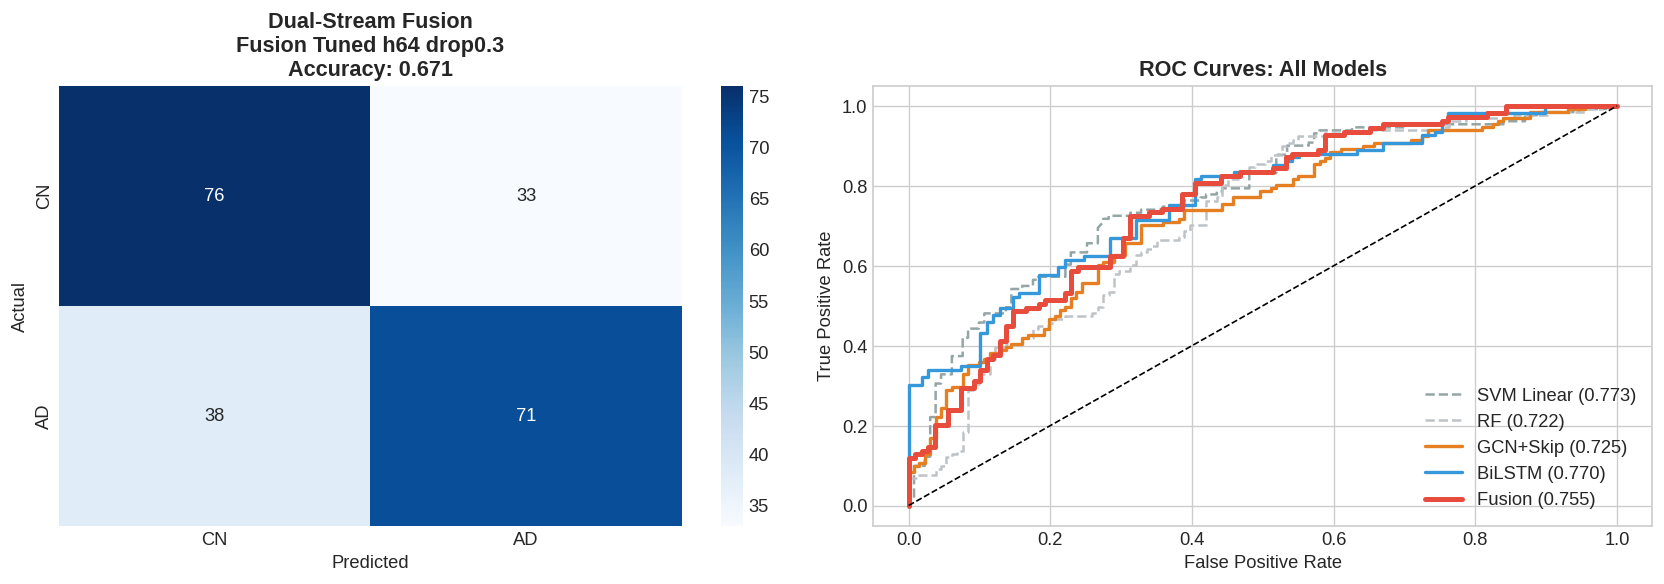

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(best_fusion['y_true_all'], best_fusion['y_pred_all'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['CN','AD'], yticklabels=['CN','AD'])
axes[0].set_title(f'Dual-Stream Fusion\n{best_fusion["model_name"]}\nAccuracy: {best_fusion["accuracy_mean"]:.3f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC - all models
for nm, data, c, ls in [
    ('SVM Linear', bl['svm_linear'], '#95a5a6', '--'),
    ('RF', bl['random_forest'], '#bdc3c7', '--'),
    ('GCN+Skip', best_gcn, '#e67e22', '-'),
    ('BiLSTM', best_bilstm, '#3498db', '-'),
]:
    fpr,tpr,_ = roc_curve(data['y_true_all'], data['y_prob_all'])
    axes[1].plot(fpr,tpr,color=c,lw=1.5 if '--' in ls else 2,ls=ls,
                label=f'{nm} ({auc(fpr,tpr):.3f})')

fpr,tpr,_ = roc_curve(best_fusion['y_true_all'], best_fusion['y_prob_all'])
axes[1].plot(fpr,tpr,color='#e74c3c',lw=3,label=f'Fusion ({auc(fpr,tpr):.3f})')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves: All Models'); axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'fusion_cm_roc.png'))
plt.show()

### 6.4 Training Curves

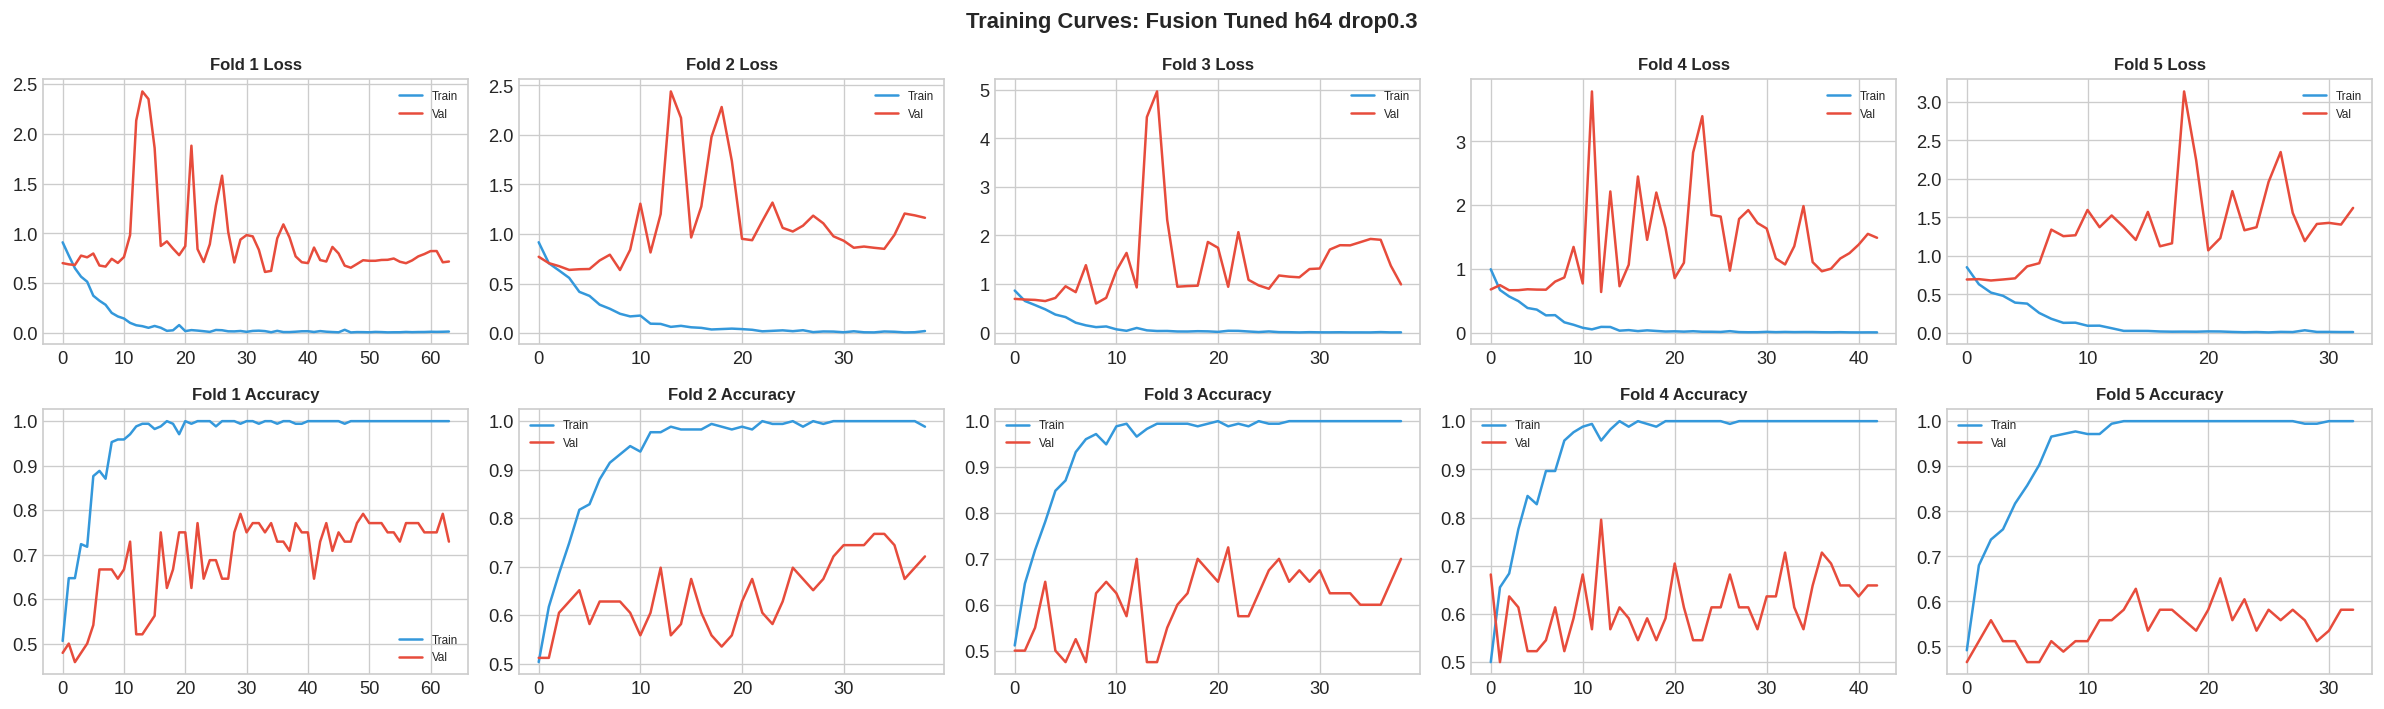

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, h in enumerate(best_fusion['fold_histories']):
    axes[0][i].plot(h['tl'],color='#3498db',label='Train')
    axes[0][i].plot(h['vl'],color='#e74c3c',label='Val')
    axes[0][i].set_title(f'Fold {i+1} Loss',fontsize=10); axes[0][i].legend(fontsize=7)
    axes[1][i].plot(h['ta'],color='#3498db',label='Train')
    axes[1][i].plot(h['va'],color='#e74c3c',label='Val')
    axes[1][i].set_title(f'Fold {i+1} Accuracy',fontsize=10); axes[1][i].legend(fontsize=7)
plt.suptitle(f'Training Curves: {best_fusion["model_name"]}', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'fusion_training_curves.png'))
plt.show()

### 6.5 All Models Bar Chart

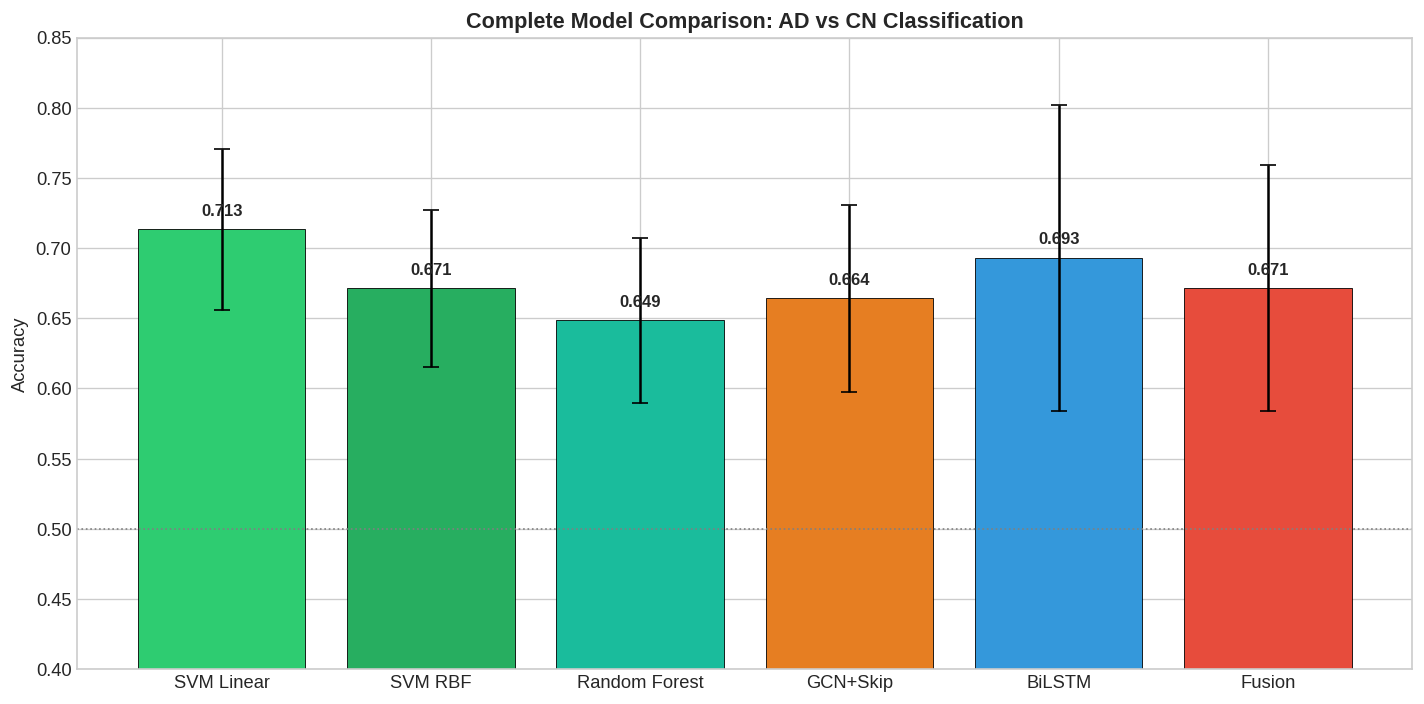

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

all_models = [
    ('SVM Linear', bl['svm_linear']['accuracy_mean'], bl['svm_linear']['accuracy_std'], '#2ecc71'),
    ('SVM RBF', bl['svm_rbf']['accuracy_mean'], bl['svm_rbf']['accuracy_std'], '#27ae60'),
    ('Random Forest', bl['random_forest']['accuracy_mean'], bl['random_forest']['accuracy_std'], '#1abc9c'),
    ('GCN+Skip', best_gcn['accuracy_mean'], best_gcn['accuracy_std'], '#e67e22'),
    ('BiLSTM', best_bilstm['accuracy_mean'], best_bilstm['accuracy_std'], '#3498db'),
    ('Fusion', best_fusion['accuracy_mean'], best_fusion['accuracy_std'], '#e74c3c'),
]

names = [m[0] for m in all_models]
accs = [m[1] for m in all_models]
stds = [m[2] for m in all_models]
colors = [m[3] for m in all_models]

bars = ax.bar(names, accs, yerr=stds, color=colors, edgecolor='black', linewidth=0.5, capsize=5)
ax.axhline(y=0.5, color='gray', ls=':', lw=1, label='Random chance')
ax.set_ylabel('Accuracy'); ax.set_title('Complete Model Comparison: AD vs CN Classification')
ax.set_ylim(0.4, 0.85)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{acc:.3f}',
            ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'all_models_comparison.png'))
plt.show()

### 6.6 Attention Weights Analysis (if applicable)

Stream Attention Weights (Fusion Tuned h64 drop0.3):
  Spatial (GCN):    0.063 (6.3%)
  Temporal (BiLSTM): 0.937 (93.7%)


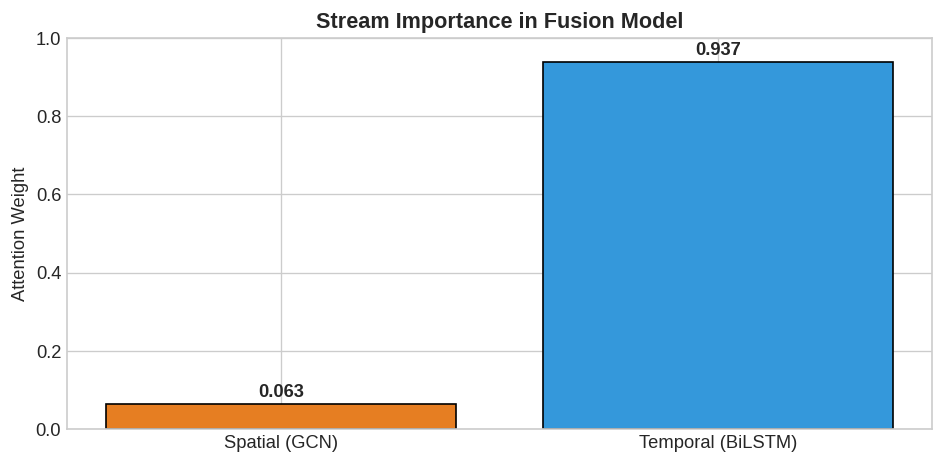

In [ ]:
# Check if any attention fusion experiments have stream weights
attn_results = [r for r in all_results if r['config']['fusion']=='attention' and len(r.get('stream_weights',[]))>0]
if attn_results:
    best_attn = max(attn_results, key=lambda r: r['accuracy_mean'])
    weights = np.concatenate(best_attn['stream_weights'], axis=0)

    spatial_w = weights[:, 0].mean()
    temporal_w = weights[:, 1].mean()

    print(f'Stream Attention Weights ({best_attn["model_name"]}):')
    print(f'  Spatial (GCN):    {spatial_w:.3f} ({spatial_w*100:.1f}%)')
    print(f'  Temporal (BiLSTM): {temporal_w:.3f} ({temporal_w*100:.1f}%)')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(['Spatial (GCN)', 'Temporal (BiLSTM)'], [spatial_w, temporal_w],
           color=['#e67e22', '#3498db'], edgecolor='black')
    ax.set_ylabel('Attention Weight'); ax.set_title('Stream Importance in Fusion Model')
    ax.set_ylim(0, 1)
    for i, v in enumerate([spatial_w, temporal_w]):
        ax.text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(NB_FIGURES, 'fusion_attention_weights.png'))
    plt.show()
else:
    print('No attention fusion results with stream weights available.')

## 7. Save All Results

In [ ]:
# Save pickle
fusion_save = {'best':best_fusion, 'all_results':all_results,
               'n_experiments':len(all_results),
               'date':datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
pkl_path = os.path.join(NB_RESULTS, 'fusion_results.pkl')
with open(pkl_path,'wb') as f: pickle.dump(fusion_save, f)
print(f'Saved: {pkl_path}')

# Append to master CSV
summary_csv = os.path.join(RESULTS_BASE, 'all_results_summary.csv')
rows = [{'model_name':r['model_name'],'model_type':'fusion','n_subjects':r['n_subjects'],
         'accuracy_mean':f"{r['accuracy_mean']:.4f}",'accuracy_std':f"{r['accuracy_std']:.4f}",
         'f1_mean':f"{r['f1_mean']:.4f}",'f1_std':f"{r['f1_std']:.4f}",
         'auc_roc_mean':f"{r['auc_roc_mean']:.4f}",'auc_roc_std':f"{r['auc_roc_std']:.4f}",
         'time_seconds':f"{r['training_time_seconds']:.0f}",'notebook':'nb04_fusion',
         'date':r['date']} for r in all_results]
new_df = pd.DataFrame(rows)
if os.path.exists(summary_csv):
    existing = pd.read_csv(summary_csv)
    existing = existing[existing['notebook']!='nb04_fusion']
    combined = pd.concat([existing, new_df], ignore_index=True)
else: combined = new_df
combined.to_csv(summary_csv, index=False)
print(f'Saved: {summary_csv}')
display(combined.style.set_caption('Master Results Summary (All Notebooks)').hide(axis='index').\
        set_properties(**{'text-align':'center'}))

# Markdown report
rpt = os.path.join(NB_RESULTS, 'fusion_report.md')
with open(rpt, 'w') as f:
    f.write('# Dual-Stream Fusion Results Report\n\n')
    f.write(f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Subjects: {N_SUBJECTS} (both streams)\n')
    f.write(f'Experiments: {len(all_results)}\n\n')
    f.write('| Rank | Model | Accuracy | F1 | AUC-ROC |\n')
    f.write('|------|-------|----------|-----|---------|\n')
    for i,r in enumerate(all_results):
        f.write(f'| {i+1} | {r["model_name"]} | {r["accuracy_mean"]:.4f}+/-{r["accuracy_std"]:.4f} | '
                f'{r["f1_mean"]:.4f}+/-{r["f1_std"]:.4f} | {r["auc_roc_mean"]:.4f}+/-{r["auc_roc_std"]:.4f} |\n')
    f.write(f'\n## Comparison\n')
    f.write(f'SVM Linear: {bl["svm_linear"]["accuracy_mean"]:.4f}\n')
    f.write(f'GCN+Skip: {best_gcn["accuracy_mean"]:.4f}\n')
    f.write(f'BiLSTM: {best_bilstm["accuracy_mean"]:.4f}\n')
    f.write(f'Best Fusion: {best_fusion["accuracy_mean"]:.4f}\n')
print(f'Saved: {rpt}')

Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb04_fusion/fusion_results.pkl
Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/all_results_summary.csv


model_name,model_type,n_subjects,accuracy_mean,accuracy_std,f1_mean,f1_std,auc_roc_mean,auc_roc_std,time_seconds,notebook,date
SVM (Linear),classical_ml,262,0.713400,0.057300,0.712600,0.057200,0.777100,0.051300,4.600000,nb01_baseline,2026-08-26 16:28:12
SVM (RBF),classical_ml,262,0.671500,0.056000,0.669700,0.055700,0.740500,0.076200,5.800000,nb01_baseline,2026-08-26 16:28:18
Random Forest,classical_ml,262,0.648500,0.058800,0.644500,0.059000,0.721100,0.059400,6.400000,nb01_baseline,2026-08-26 16:28:25
GCN+Skip Thresh-0.2 h64 L2,gcn,262,0.664200,0.066400,0.653200,0.070200,0.740100,0.069500,28.000000,nb02_gcn,2026-08-26 16:38:39
Tuned h64 L3 d0.5,gcn,262,0.640900,0.064200,0.611800,0.106300,0.714400,0.067900,20.000000,nb02_gcn,2026-08-26 16:40:12
Tuned h128 L2 d0.5,gcn,262,0.626200,0.036600,0.622000,0.039100,0.670600,0.088100,17.000000,nb02_gcn,2026-08-26 16:39:52
GCN+Skip KNN-10 h64 L2,gcn,262,0.619200,0.129700,0.537700,0.198800,0.671900,0.154000,20.000000,nb02_gcn,2026-08-26 16:38:11
GAT+Skip KNN-10-bin h64 L2,gcn,262,0.610700,0.033000,0.579700,0.053600,0.675200,0.051000,21.000000,nb02_gcn,2026-08-26 16:39:21
SAGE+Skip KNN-10 h64 L2,gcn,262,0.606900,0.084700,0.538500,0.166500,0.660000,0.109500,14.000000,nb02_gcn,2026-08-26 16:39:35
Tuned h64 L2 d0.3,gcn,262,0.599300,0.088300,0.574000,0.111800,0.664100,0.091800,17.000000,nb02_gcn,2026-08-26 16:40:29


Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb04_fusion/fusion_report.md


### 7.1 Summary

In [ ]:
n_figs = len([f for f in os.listdir(NB_FIGURES) if f.endswith('.png')])

print('='*55)
print('NOTEBOOK COMPLETE: DUAL-STREAM FUSION')
print('='*55)

final = pd.DataFrame({
    'Item': ['Subjects (both streams)','Spatial input','Temporal input',
             'Experiments','Best Model','Best Accuracy','Best AUC-ROC',
             'vs SVM Linear','vs GCN+Skip','vs BiLSTM','Figures'],
    'Value': [N_SUBJECTS, f'{M}x{M} FC graph', f'{T}x{N_ROIS} BOLD',
              len(all_results), best_fusion['model_name'],
              f"{best_fusion['accuracy_mean']:.4f}+/-{best_fusion['accuracy_std']:.4f}",
              f"{best_fusion['auc_roc_mean']:.4f}+/-{best_fusion['auc_roc_std']:.4f}",
              f"{best_fusion['accuracy_mean']-bl['svm_linear']['accuracy_mean']:+.4f}",
              f"{best_fusion['accuracy_mean']-best_gcn['accuracy_mean']:+.4f}",
              f"{best_fusion['accuracy_mean']-best_bilstm['accuracy_mean']:+.4f}",
              n_figs]
})
display(final.style.set_caption('Fusion Notebook Summary').hide(axis='index').\
        set_properties(**{'text-align':'left'}))

print(f'\nResults: {NB_RESULTS}')
print(f'  fusion_results.pkl | fusion_report.md | fusion_all_experiments.csv | {n_figs} figures')
print(f'\nNext: Notebook 5 - Final Comparison and Explainability (XAI)')

NOTEBOOK COMPLETE: DUAL-STREAM FUSION


Item,Value
Subjects (both streams),218
Spatial input,132x132 FC graph
Temporal input,191x132 BOLD
Experiments,8
Best Model,Fusion Tuned h64 drop0.3
Best Accuracy,0.6713+/-0.0877
Best AUC-ROC,0.7379+/-0.0800
vs SVM Linear,-0.0421
vs GCN+Skip,+0.0071
vs BiLSTM,-0.0218



Results: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb04_fusion
  fusion_results.pkl | fusion_report.md | fusion_all_experiments.csv | 4 figures

Next: Notebook 5 - Final Comparison and Explainability (XAI)
